# Kinetochore Gene Expression Across Human Brain Development
**Author:** Sai Sasi Sekhar Kongala
**MSc Brain Science, University of Glasgow**
**Date:** 22-05-2026

## Project Question
Do kinetochore protein rermain expressed in the post-mitotic human brain, 
syggesting roles beyond cell division?
## Background
Kinetochore proteins are classically known for chromosome 
segregation during cell division. However, the Cheerambathur lab 
showed these proteins also function in post-mitotic neurons. 
This analysis investigates whether human kinetochore genes show 
persistent expression in the adult brain using real BrainSpan 
developmental transcriptomics data.
## Data Source
- BrainSpan Atlas of the Developing Human Brain
- 524 brain tissue samples
- 31 developmental stages (8 pcw to 40 years)
- Downloaded from: brainspan.org

In [2]:
#importing lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [33]:
#loading data
load_data = "C:/Users/ssrko/Downloads/kinetochore_project/Data/genes_matrix_csv/"
                                                         

expression = pd.read_csv(load_data + "expression_matrix.csv",
                         header=None, index_col=0)

rows = pd.read_csv(load_data + "rows_metadata.csv")      

columns = pd.read_csv(load_data + "columns_metadata.csv")

print("Expression matrix shape:", expression.shape)
print("Rows metadata shape:", rows.shape)
print("Columns metadata shape:", columns.shape)

Expression matrix shape: (52376, 524)
Rows metadata shape: (52376, 5)
Columns metadata shape: (524, 8)


In [40]:
expression.head()
rows.head()
columns.head()
print("Rows metadata columns:", rows.columns.tolist())
print("Cloumn metadata columns:", columns.columns.tolist())

Rows metadata columns: ['row_num', 'gene_id', 'ensembl_gene_id', 'gene_symbol', 'entrez_id']
Cloumn metadata columns: ['column_num', 'donor_id', 'donor_name', 'age', 'gender', 'structure_id', 'structure_acronym', 'structure_name']


In [41]:
#filterting
kinetochore_genes = ["NDC80", "NUF2", "SPC24", "SPC25",
                    "BUB1", "BUB1B", "BUB3", "CASC5",
                    "MAD2L1", "CENPE", "CENPF"]
print(f"we are studying {len(kinetochore_genes)} genes")

we are studying 11 genes


In [43]:
kt_rows = rows[rows["gene_symbol"].isin(kinetochore_genes)]

print("Gene found in BrainSpan:")
print(kt_rows["gene_symbol"].tolist())
print (f"\nFound{len(kt_rows)} matches out of {len(kinetochore_genes)}")

Gene found in BrainSpan:
['NDC80', 'CENPF', 'CASC5', 'CENPE', 'NUF2', 'SPC25', 'BUB3', 'BUB1B', 'SPC24', 'MAD2L1', 'BUB1']

Found11 matches out of 11


In [46]:
#Merging
kt_rows_numbers = kt_rows["row_num"].tolist()
print("Row numbers for our genes:")
print(kt_rows_numbers)

Row numbers for our genes:
[1531, 4798, 7612, 7815, 8432, 9612, 9873, 10154, 10767, 11377, 12797]


In [48]:
kt_expression = expression.loc[kt_rows_numbers]

print("Shape before filtering:", expression.shape)
print("Shape after filtering:", kt_expression.shape)

Shape before filtering: (52376, 524)
Shape after filtering: (11, 524)


In [49]:
kt_expression.index = kt_rows["gene_symbol"].tolist()

print("Our expression matrox now looks like:")
kt_expression.head()

Our expression matrox now looks like:


,1,2,3,4,5,6,7,8,9,10,...,515,516,517,518,519,520,521,522,523,524
NDC80,33.281054,31.102038,16.443420,35.914617,15.974436,5.101369,37.893076,18.465074,35.571133,35.383076,...,0.000000,0.067065,0.022531,0.039958,0.136731,0.044914,0.000000,0.000000,0.021958,0.020773
CENPF,12.670080,33.745434,11.643586,28.206196,15.237312,6.551236,35.534019,12.755906,12.083452,6.025163,...,0.085928,0.043561,0.098533,0.292807,0.191026,0.380178,0.104126,0.162262,0.091898,0.179287
CASC5,4.156455,7.630898,2.314832,7.749644,3.544920,0.866993,8.181354,3.493493,3.848463,2.762774,...,0.007510,0.000000,0.004834,0.017146,0.016171,0.014856,0.000000,0.015032,0.014327,0.004457
CENPE,1.807244,7.940889,1.353307,3.967262,2.822886,1.166656,5.275697,1.777610,2.125439,1.618072,...,0.035392,0.046733,0.179011,0.124544,0.126328,0.131981,0.064195,0.118902,0.215753,0.105303
NUF2,21.423875,16.264869,7.900186,20.352315,9.510000,2.545004,19.388288,11.220636,20.111794,25.386863,...,0.141041,0.087502,0.104298,0.090354,0.097172,0.134598,0.090148,0.167179,0.241756,0.156392


In [52]:
print(columns["age"].unique())
columns.index = columns["column_num"]
print(columns.head())

kt_t = kt_expression.T
print("Shape after transposing:", kt_t.shape)
kt_t.head()

['8 pcw' '9 pcw' '12 pcw' '13 pcw' '16 pcw' '17 pcw' '19 pcw' '21 pcw'
 '24 pcw' '25 pcw' '26 pcw' '35 pcw' '37 pcw' '4 mos' '10 mos' '1 yrs'
 '2 yrs' '3 yrs' '4 yrs' '8 yrs' '11 yrs' '13 yrs' '15 yrs' '18 yrs'
 '19 yrs' '21 yrs' '23 yrs' '30 yrs' '36 yrs' '37 yrs' '40 yrs']
            column_num  donor_id   donor_name    age gender  structure_id  \
column_num                                                                  
1                    1     13058  H376.IIA.51  8 pcw      M         10268   
2                    2     13058  H376.IIA.51  8 pcw      M         10291   
3                    3     13058  H376.IIA.51  8 pcw      M         10361   
4                    4     13058  H376.IIA.51  8 pcw      M         10550   
5                    5     13058  H376.IIA.51  8 pcw      M         10243   

           structure_acronym  \
column_num                     
1                        Ocx   
2                    M1C-S1C   
3                        AMY   
4                       

,NDC80,CENPF,CASC5,CENPE,NUF2,SPC25,BUB3,BUB1B,SPC24,MAD2L1,BUB1
1,33.281054,12.670080,4.156455,1.807244,21.423875,25.699802,55.302385,18.150998,31.843302,45.461143,17.704531
2,31.102038,33.745434,7.630898,7.940889,16.264869,20.301101,41.606645,20.306823,24.647320,24.718352,16.892150
3,16.443420,11.643586,2.314832,1.353307,7.900186,9.548942,28.612834,9.990347,16.994593,14.067699,8.390801
4,35.914617,28.206196,7.749644,3.967262,20.352315,22.888333,46.408275,21.853940,35.568266,38.044635,19.417889
5,15.974436,15.237312,3.544920,2.822886,9.510000,12.031538,34.491700,11.094933,14.021394,15.162299,9.912469


In [53]:
#Add age,brain region and phase column: prenatal vs postnatal

kt_t["age"] = columns.loc[kt_t.index, "age"]
kt_t["brain_region"] = columns.loc[kt_t.index, "structure_name"]
kt_t["structure_acronym"] = columns.loc[kt_t.index, "structure_acronym"]
kt_t["phase"] = kt_t["age"].str.contains("pcw").map({True: "Prenatal", 
                                                      False: "Postnatal"})

print("Shape now:", kt_t.shape)
kt_t.head()
print(kt_t["phase"].value_counts())

Shape now: (524, 15)
phase
Postnatal    287
Prenatal     237
Name: count, dtype: int64


In [ ]:
kt_t.to_csv("data/kinetochore_clean.csv")
print("Data saved successfully!")
print(f"Final table shape: {kt_t.shape}")

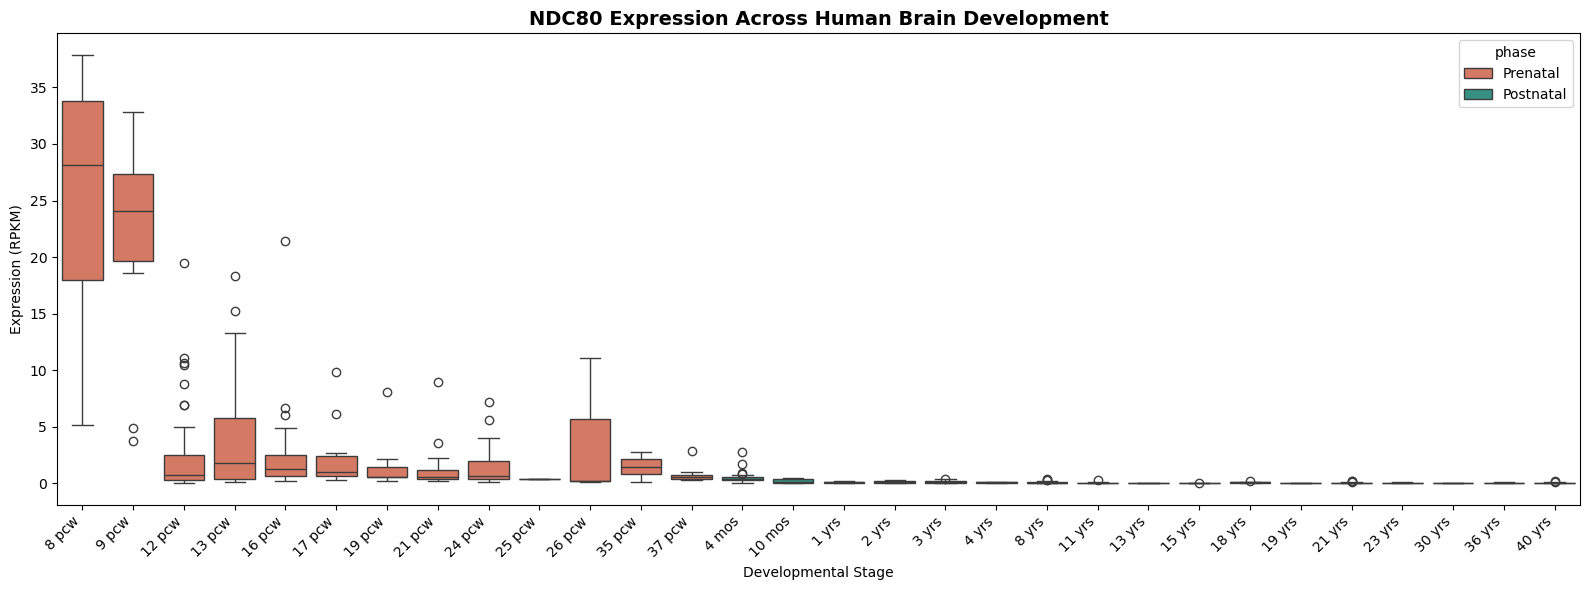

Plot saved!


In [60]:
# Define a logical age order for the x axis
age_order = ['8 pcw','9 pcw','12 pcw','13 pcw','16 pcw','17 pcw',
             '19 pcw','21 pcw','24 pcw','25 pcw','26 pcw','35 pcw',
             '37 pcw','4 mos','10 mos','1 yrs','2 yrs','3 yrs',
             '4 yrs','8 yrs','11 yrs','13 yrs','15 yrs','18 yrs',
             '19 yrs','21 yrs','23 yrs','30 yrs','36 yrs','40 yrs']

# Set figure size
plt.figure(figsize=(16, 6))

# Draw the plot
sns.boxplot(data=kt_t, 
            x="age", 
            y="NDC80",
            hue="phase",
            order=age_order,
            palette={"Prenatal": "#E76F51", "Postnatal": "#2A9D8F"})

# Labels
plt.title("NDC80 Expression Across Human Brain Development", 
          fontsize=14, fontweight="bold")
plt.xlabel("Developmental Stage")
plt.ylabel("Expression (RPKM)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("C:/Users/ssrko/Downloads/kinetochore_project/Figures/NDC80_trajectory.png", dpi=300)
plt.show()

print("Plot saved!")

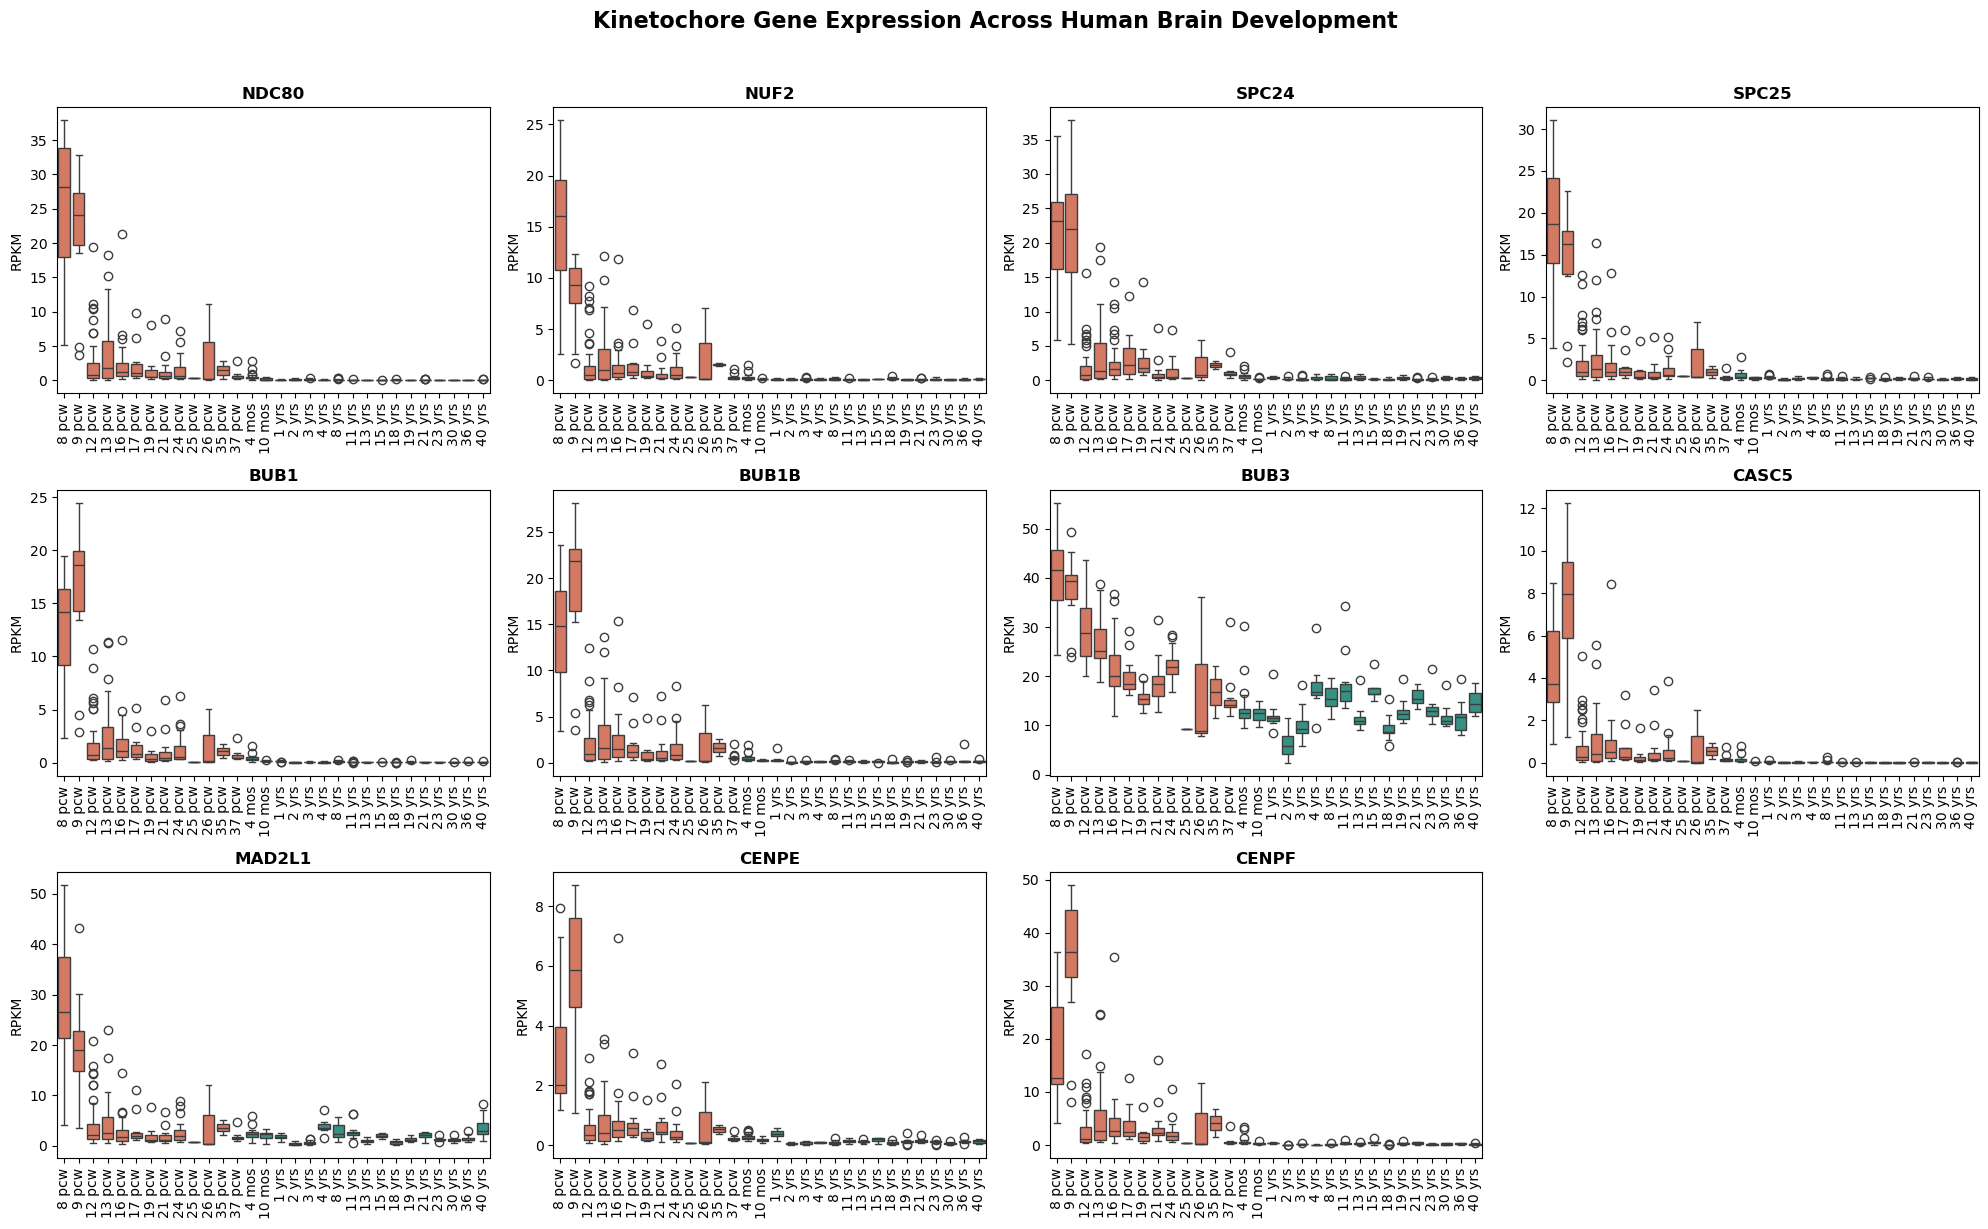

Saved!


In [62]:
# We will make one plot per gene, arranged in a grid
# 11 genes = 3 rows of 4 plots (last spot empty)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

# flatten() converts the 3x4 grid into a simple list
# so we can loop through it easily
axes = axes.flatten()

genes_to_plot = ["NDC80", "NUF2", "SPC24", "SPC25",
                 "BUB1", "BUB1B", "BUB3", "CASC5",
                 "MAD2L1", "CENPE", "CENPF"]

for i, gene in enumerate(genes_to_plot):
    sns.boxplot(data=kt_t,
                x="age",
                y=gene,
                hue="phase",
                order=age_order,
                palette={"Prenatal": "#E76F51", "Postnatal": "#2A9D8F"},
                ax=axes[i],
                legend=False)
    
    axes[i].set_title(gene, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("RPKM")
    axes[i].tick_params(axis="x", rotation=90)

# Hide the empty 12th plot
axes[11].set_visible(False)

plt.suptitle("Kinetochore Gene Expression Across Human Brain Development",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("C:/Users/ssrko/Downloads/kinetochore_project/Figures/all_genes.png", 
            dpi=300)
plt.show()
print("Saved!")

In [63]:
for i, gene in enumerate(["NDC80", "NUF2", "SPC24"]):
    print(i, gene)

0 NDC80
1 NUF2
2 SPC24


In [66]:
#Statistical Testing
results = []

for gene in genes_to_plot:
    
    # Split data into two groups
    prenatal  = kt_t[kt_t["phase"] == "Prenatal"][gene]
    postnatal = kt_t[kt_t["phase"] == "Postnatal"][gene]
    
    # Run the statistical test
    stat, p = mannwhitneyu(prenatal, postnatal, alternative="greater")
    
    # Calculate fold change - how many times higher is prenatal?
    fold_change = prenatal.mean() / postnatal.mean()
    
    # Store results
    results.append({
        "gene":           gene,
        "prenatal_mean":  round(prenatal.mean(), 3),
        "postnatal_mean": round(postnatal.mean(), 3),
        "fold_change":    round(fold_change, 2),
        "p_value":        round(p, 6),
        "significant":    p < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("C:/Users/ssrko/Downloads/kinetochore_project/results/statistical_results.csv",
                  index=False)
print("Results saved!")

      gene  prenatal_mean  postnatal_mean  fold_change  p_value  significant
0    NDC80          5.089           0.112        45.49      0.0         True
1     NUF2          2.747           0.135        20.29      0.0         True
2    SPC24          4.773           0.317        15.07      0.0         True
3    SPC25          3.621           0.242        14.96      0.0         True
4     BUB1          3.263           0.105        31.22      0.0         True
5    BUB1B          3.878           0.187        20.75      0.0         True
6     BUB3         25.172          12.946         1.94      0.0         True
7    CASC5          1.361           0.035        38.36      0.0         True
8   MAD2L1          5.921           1.823         3.25      0.0         True
9    CENPE          1.081           0.140         7.75      0.0         True
10   CENPF          6.287           0.272        23.15      0.0         True
Results saved!


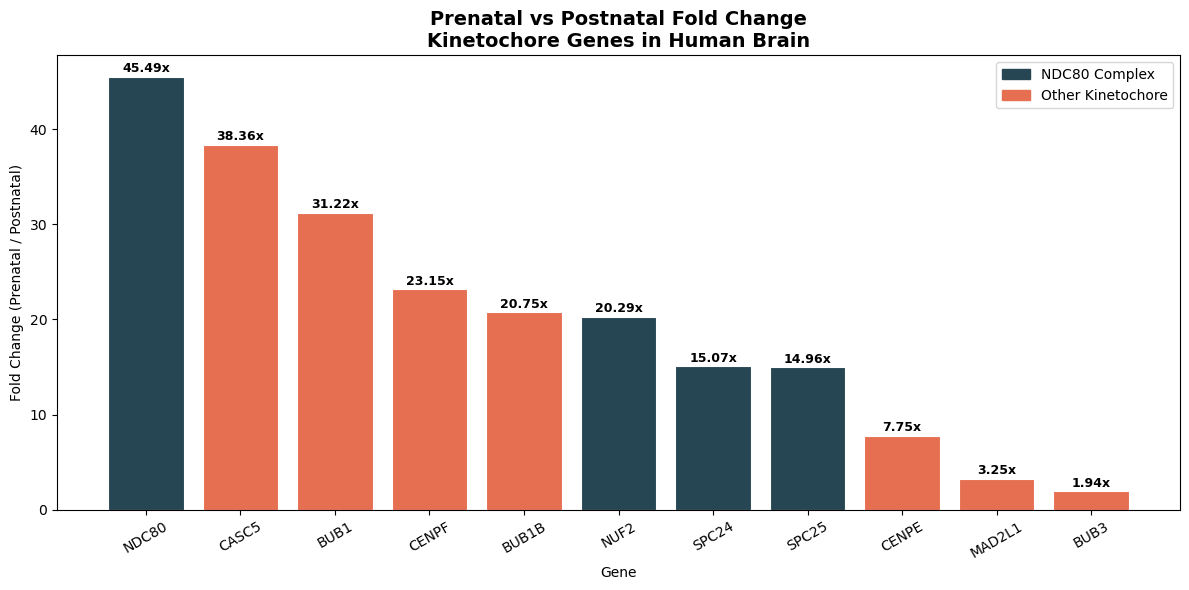

Saved!


In [67]:
plt.figure(figsize=(12, 6))

# Sort by fold change so biggest bars are first
results_sorted = results_df.sort_values("fold_change", ascending=False)

# Colour bars by whether they are NDC80 complex or not
colours = []
ndc80_complex = ["NDC80", "NUF2", "SPC24", "SPC25"]

for gene in results_sorted["gene"]:
    if gene in ndc80_complex:
        colours.append("#264653")   # dark = NDC80 complex
    else:
        colours.append("#E76F51")   # orange = other kinetochore

bars = plt.bar(results_sorted["gene"], 
               results_sorted["fold_change"],
               color=colours,
               edgecolor="white",
               linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, results_sorted["fold_change"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val}x",
             ha="center", fontsize=9, fontweight="bold")

plt.title("Prenatal vs Postnatal Fold Change\nKinetochore Genes in Human Brain",
          fontsize=14, fontweight="bold")
plt.ylabel("Fold Change (Prenatal / Postnatal)")
plt.xlabel("Gene")
plt.xticks(rotation=30)

# Add legend
import matplotlib.patches as mpatches
ndc80_patch  = mpatches.Patch(color="#264653", label="NDC80 Complex")
other_patch  = mpatches.Patch(color="#E76F51", label="Other Kinetochore")
plt.legend(handles=[ndc80_patch, other_patch])

plt.tight_layout()
plt.savefig("C:/Users/ssrko/Downloads/kinetochore_project/Figures/fold_change.png",
            dpi=300)
plt.show()
print("Saved!")